# Autotune con voz de Miku — corregir la afinación y ponerle timbre de Miku (DSP puro)

**Procesamiento Digital de Señales e Imágenes (INFB6063) — UTEM 2026-1**
Francisco Alejandro Pinto Abraham · RUT 21.571.239-7

Este cuaderno es un **autotune**: toma **tu voz** cantada, (1) sigue su **tono** cuadro a cuadro,
(2) lo **pega a las notas** de una escala musical (el "snap" del autotune), (3) corrige el tono de
forma **variable en el tiempo** con un **phase vocoder** que **preserva los formantes**, y
(4) le transfiere el **timbre (formantes) de Hatsune Miku**. Resultado: tu misma interpretación, pero
**afinada** y con **voz de Miku**.

**Regla del ramo:** todo es DSP clásico — **FFT** (rfft/irfft), **STFT**/enventanado Hann,
**phase vocoder** (Dolson 1986), **cepstrum** (formantes), **overlap-add**, **autocorrelación/pYIN**
para el tono. **Sin** deep learning ni IA generativa (RVC, so-vits, etc. quedan solo como *trabajo futuro*).

> **En vivo con audios nuevos:** en Colab puedes **subir** un `.wav`/`.mp3` de tu voz o **grabar con el
> micrófono** (`USE_MIC = True`). En local usa `LOCAL_PATH` o corre con la voz de prueba. Trae **incluida
> la voz real de Miku** (Vocaloid 4 CyberDiva) como referencia de timbre, así suena a Miku sin subir nada.
> **Colab: Entorno de ejecución → Ejecutar todo.**


## 0. Dependencias

In [1]:
try:
    import google.colab  # noqa
    !pip install -q librosa soundfile numpy scipy matplotlib
except Exception:
    pass
print("Dependencias listas.")


Dependencias listas.


In [2]:
import os, io, base64, urllib.request, warnings
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display
warnings.filterwarnings("ignore")
try:
    import google.colab  # noqa
    IN_COLAB = True
except Exception:
    IN_COLAB = False
print("IN_COLAB =", IN_COLAB)


IN_COLAB = False


## 1. Núcleo DSP (phase vocoder + formantes)
Mismas funciones validadas en `vocoder.py` (Dolson 1986 + preservación de formantes).

In [3]:
# -*- coding: utf-8 -*-
"""
vocoder.py -- Núcleo DSP del proyecto "Phase Vocoder (Dolson 1986) + Pedal Miku".

Procesamiento Digital de Señales e Imágenes (INFB6063) -- UTEM 2026-1
Estudiante: Francisco Alejandro Pinto Abraham -- RUT 21.571.239-7

Contiene:
  1) Utilidades de señal y análisis de Fourier REUTILIZADAS del proyecto previo
     `miku_pedal.ipynb` (declaradas explícitamente como código reutilizado).
  2) La REPRODUCCIÓN del phase vocoder de Dolson (STFT -> frecuencia instantánea por
     fase -> time-stretch -> pitch-shift).
  3) La EXTENSIÓN propia: phase vocoder con preservación de formantes (corrección de
     envolvente espectral por cepstrum).
  4) Tres métodos de pitch-shift comparables: remuestreo ingenuo (baseline),
     phase vocoder, y phase vocoder + formantes.
  5) Métricas de evaluación (error de f0 en cents, error de duración, centroide de la
     envolvente, distancia log-espectral).

Todo es DSP clásico del curso: DFT/FFT, STFT, enventanado Hann, fase, cepstrum,
overlap-add, muestreo/interpolación. Sin ML / deep learning / LLM.
"""

import os
import numpy as np

SR = 22050                       # frecuencia de muestreo de trabajo (Hz)
EPS = 1e-9

# Mapa vocal -> formantes (fc, ancho de banda, ganancia). Reutilizado de miku_pedal.ipynb.
VOWEL_FORMANTS = {
    'a': ((800.0, 90.0, 1.00), (1150.0, 110.0, 0.82), (2900.0, 240.0, 0.38)),
    'e': ((500.0, 80.0, 0.95), (1750.0, 150.0, 0.88), (2450.0, 220.0, 0.34)),
    'i': ((320.0, 70.0, 0.92), (2200.0, 170.0, 0.95), (3000.0, 260.0, 0.42)),
    'o': ((500.0, 80.0, 0.96), (900.0, 110.0, 0.82), (2600.0, 240.0, 0.32)),
    'u': ((350.0, 70.0, 0.96), (800.0, 100.0, 0.78), (2200.0, 230.0, 0.28)),
}


# =====================================================================================
# 1) UTILIDADES REUTILIZADAS de miku_pedal.ipynb  (declaradas como código reutilizado)
# =====================================================================================
def ensure_mono_float(audio):
    """Fuerza la señal a mono float32 y limpia NaN/Inf. [Reutilizado de miku_pedal.ipynb]"""
    a = np.asarray(audio, dtype=np.float32)
    if a.ndim > 1:
        a = np.mean(a, axis=-1)
    return np.nan_to_num(a, nan=0.0, posinf=0.0, neginf=0.0).flatten().astype(np.float32)


def normalize_audio(audio, peak=0.95, eps=EPS):
    """Escala la señal para que su pico no supere 'peak'. [Reutilizado de miku_pedal.ipynb]"""
    a = ensure_mono_float(audio)
    if a.size == 0:
        return a
    m = float(np.max(np.abs(a)))
    return a.copy() if m < eps else (a / m * peak).astype(np.float32)


def apply_short_fade(audio, fade=64):
    """Fade-in/out lineal para unir granos sin clicks. [Reutilizado de miku_pedal.ipynb]"""
    a = ensure_mono_float(audio)
    f = int(min(max(fade, 0), a.size // 2))
    if f <= 1:
        return a
    ramp = np.linspace(0.0, 1.0, f, dtype=np.float32)
    a[:f] *= ramp
    a[-f:] *= ramp[::-1]
    return a


def compute_rfft(x, fs=SR):
    """DFT de señal real: devuelve frecuencias (Hz) y magnitud. [Reutilizado de miku_pedal.ipynb]"""
    x = ensure_mono_float(x)
    X = np.fft.rfft(x)
    f = np.fft.rfftfreq(len(x), d=1.0 / fs)
    return f, np.abs(X)


def spectrum_peaks_valleys(x, fs=SR, n_peaks=6, fmin=70.0, fmax=2000.0):
    """Máximos (picos) y mínimos (valles) locales del espectro. [Reutilizado de miku_pedal.ipynb]"""
    f, mag = compute_rfft(x, fs)
    band = (f >= fmin) & (f <= fmax)
    fb, mb = f[band], mag[band]
    peaks = [i for i in range(1, len(mb) - 1) if mb[i] > mb[i - 1] and mb[i] >= mb[i + 1]]
    valleys = [i for i in range(1, len(mb) - 1) if mb[i] < mb[i - 1] and mb[i] <= mb[i + 1]]
    top = sorted(sorted(peaks, key=lambda i: -mb[i])[:n_peaks])
    return fb, mb, np.array(top, dtype=int), np.array(valleys, dtype=int)


def apply_formants(src, sr, vowel):
    """Color de vocal por máscara de formantes en frecuencia. [Reutilizado de miku_pedal.ipynb]"""
    src = ensure_mono_float(src)
    n = len(src)
    if n < 4:
        return src
    spec = np.fft.rfft(src)
    freqs = np.fft.rfftfreq(n, d=1.0 / sr)
    H = np.full_like(freqs, 0.05, dtype=np.float64)
    for fc, bw, g in VOWEL_FORMANTS.get(vowel, VOWEL_FORMANTS['a']):
        H += g * np.exp(-0.5 * ((freqs - fc) / max(bw, 1.0)) ** 2)
    return np.fft.irfft(spec * H, n=n).astype(np.float32)


def build_guitar_unit_db(x, sr, unit_ms=140, hop_ms=70, fmin=70.0, fmax=1000.0, gate=0.12):
    """Base de 'difonos': granos de guitarra enventanados con f0 y energía. [Reutilizado]"""
    x = ensure_mono_float(x)
    L = max(64, int(unit_ms / 1000.0 * sr))
    H = max(1, int(hop_ms / 1000.0 * sr))
    win = np.hanning(L).astype(np.float32)
    freqs = np.fft.rfftfreq(L, d=1.0 / sr)
    band = (freqs >= fmin) & (freqs <= fmax)
    grains = [(s, x[s:s + L] * win) for s in range(0, len(x) - L, H)]
    if not grains:
        return []
    energies = [float(np.sqrt(np.mean(g ** 2))) for _, g in grains]
    thr = max(energies) * float(gate)
    db = []
    for (s, g), e in zip(grains, energies):
        if e < thr:
            continue
        mag = np.abs(np.fft.rfft(g))
        mb = np.where(band, mag, 0.0)
        db.append({'wave': g.astype(np.float32), 'f0': float(freqs[int(np.argmax(mb))]), 'energy': e})
    return db


def track_dominant_per_frame(x, fs=SR, frame=2048, hop=1024, fmin=70.0, fmax=2000.0):
    """Frecuencia dominante y energía por tramo (STFT). [Reutilizado de miku_pedal.ipynb]"""
    x = ensure_mono_float(x)
    if len(x) < frame:
        x = np.pad(x, (0, frame - len(x)))
    win = np.hanning(frame).astype(np.float32)
    freqs = np.fft.rfftfreq(frame, d=1.0 / fs)
    band = (freqs >= fmin) & (freqs <= fmax)
    times, f0, energy = [], [], []
    for s in range(0, len(x) - frame + 1, hop):
        fr = x[s:s + frame] * win
        mag = np.abs(np.fft.rfft(fr))
        mb = np.where(band, mag, 0.0)
        f0.append(float(freqs[int(np.argmax(mb))]))
        energy.append(float(np.sqrt(np.mean(fr ** 2))))
        times.append((s + frame / 2) / fs)
    return np.array(times), np.array(f0), np.array(energy)


def select_unit(db, f_target):
    """Selecciona el difono de f0 más cercana al objetivo. [Reutilizado de miku_pedal.ipynb]"""
    return min(db, key=lambda u: abs(u['f0'] - f_target))


def mix_over(dry, wet, mix=0.6):
    """Mezcla guitarra seca + voz concatenativa. [Reutilizado de miku_pedal.ipynb]"""
    dry = ensure_mono_float(dry)
    wet = ensure_mono_float(wet)
    L = max(len(dry), len(wet))
    d = np.zeros(L, dtype=np.float32); d[:len(dry)] = dry
    w = np.zeros(L, dtype=np.float32); w[:len(wet)] = wet
    return normalize_audio((1.0 - mix) * d + mix * w)


# =====================================================================================
# 2) STFT / ISTFT  (núcleo de análisis-síntesis, materia del curso: U2-L1)
# =====================================================================================
def stft(x, n_fft=1024, hop=256, win=None):
    """Qué hace: Transformada de Fourier de Tiempo Corto.
    Curso: Unit 2 - Lecture 1 (STFT/enventanado), Unit 1 - L3 (DFT).
    Matemática: X[m,k] = sum_n x[n + m*hop] w[n] e^{-j 2π k n / Nfft}. Devuelve (frames, bins).
    """
    x = ensure_mono_float(x)
    if win is None:
        win = np.hanning(n_fft).astype(np.float32)
    if len(x) < n_fft:
        x = np.pad(x, (0, n_fft - len(x)))
    n_frames = 1 + (len(x) - n_fft) // hop
    cols = []
    for m in range(n_frames):
        s = m * hop
        cols.append(np.fft.rfft(x[s:s + n_fft] * win))
    return np.array(cols)


def istft(X, n_fft=1024, hop=256, win=None, length=None):
    """Qué hace: reconstrucción por superposición-suma (overlap-add) con normalización de ventana.
    Curso: Unit 2 - Lecture 1/2 (enventanado y superposición).
    Matemática: x[n] = sum_m (IDFT(X[m]) w[n]) / sum_m w[n]^2  (OLA con ventana al cuadrado).
    """
    if win is None:
        win = np.hanning(n_fft).astype(np.float32)
    n_frames = X.shape[0]
    out_len = n_fft + hop * (n_frames - 1)
    y = np.zeros(out_len, dtype=np.float64)
    wsum = np.zeros(out_len, dtype=np.float64)
    for m in range(n_frames):
        frame = np.fft.irfft(X[m], n=n_fft)
        s = m * hop
        y[s:s + n_fft] += frame * win
        wsum[s:s + n_fft] += win ** 2
    y = y / np.where(wsum > EPS, wsum, 1.0)
    if length is not None:
        y = y[:length] if len(y) >= length else np.pad(y, (0, length - len(y)))
    return y.astype(np.float32)


# =====================================================================================
# 3) PHASE VOCODER  (REPRODUCCIÓN de Dolson 1986)
# =====================================================================================
def phase_vocoder(X, stretch, hop, n_fft):
    """Qué hace: estira/comprime en el tiempo una STFT preservando la frecuencia, propagando la fase
    por la FRECUENCIA INSTANTÁNEA (corazón del phase vocoder de Dolson 1986).
    Curso: Unit 2 - L1 (STFT), Unit 1 - L2/3 (fase de la DFT), enventanado.
    Matemática: para cada bin k, la fase esperada por salto es Δφ_esp = 2π·hop·k/Nfft. La desviación
    medida Δφ - Δφ_esp se envuelve a (-π,π] (heterodinaje) y da la frecuencia instantánea; la fase de
    síntesis se acumula con ese incremento. La magnitud se interpola linealmente entre tramas.

    stretch > 1 -> salida más larga (más lenta);  stretch < 1 -> más corta (más rápida).
    """
    n_frames, n_bins = X.shape
    omega = 2.0 * np.pi * hop * np.arange(n_bins) / n_fft       # avance de fase esperado por bin
    Xpad = np.vstack([X, np.zeros((1, n_bins), dtype=X.dtype)])  # tramo extra para interpolar
    steps = np.arange(0, n_frames, 1.0 / stretch)               # posiciones de análisis (fraccionarias)
    out = np.zeros((len(steps), n_bins), dtype=np.complex128)
    phase_acc = np.angle(Xpad[0])
    for i, step in enumerate(steps):
        f0 = int(np.floor(step))
        frac = step - f0
        mag = (1.0 - frac) * np.abs(Xpad[f0]) + frac * np.abs(Xpad[f0 + 1])
        out[i] = mag * np.exp(1j * phase_acc)
        dphase = np.angle(Xpad[f0 + 1]) - np.angle(Xpad[f0]) - omega
        dphase = dphase - 2.0 * np.pi * np.round(dphase / (2.0 * np.pi))   # envolver a (-π,π]
        phase_acc = phase_acc + omega + dphase
    return out


def time_stretch_pv(x, stretch, n_fft=1024, hop=256):
    """Qué hace: cambia la DURACIÓN sin cambiar el tono, vía phase vocoder.
    Curso: Unit 2 - L1 (STFT/OLA), Dolson 1986. stretch>1 = más largo.
    """
    x = ensure_mono_float(x)
    if x.size < n_fft:
        x = np.pad(x, (0, n_fft - x.size))
    win = np.hanning(n_fft).astype(np.float32)
    X = stft(x, n_fft=n_fft, hop=hop, win=win)
    Xs = phase_vocoder(X, stretch, hop=hop, n_fft=n_fft)
    target = int(round(len(x) * stretch))
    return istft(Xs, n_fft=n_fft, hop=hop, win=win, length=target)


def _resample_linear(x, n_out):
    """Remuestreo por interpolación lineal a 'n_out' muestras (muestreo, U1-L3)."""
    x = ensure_mono_float(x)
    if x.size < 2 or n_out < 2:
        return x
    idx = np.linspace(0.0, x.size - 1, int(n_out))
    return np.interp(idx, np.arange(x.size), x).astype(np.float32)


def pitch_shift_pv(x, n_semitones, n_fft=1024, hop=256):
    """Qué hace: PITCH-SHIFT preservando la DURACIÓN (método de Dolson): time-stretch + remuestreo.
    Curso: Dolson 1986; Unit 2 - L1 (STFT), Unit 1 - L3 (remuestreo).
    Matemática: ratio = 2^(n/12). Se estira el tiempo por 'ratio' (queda más largo) y luego se
    remuestrea de vuelta a la longitud original -> los armónicos suben por 'ratio' y la duración se conserva.
    """
    x = ensure_mono_float(x)
    ratio = 2.0 ** (float(n_semitones) / 12.0)
    if abs(n_semitones) < 1e-6 or x.size < n_fft:
        return x
    stretched = time_stretch_pv(x, ratio, n_fft=n_fft, hop=hop)
    return _resample_linear(stretched, len(x))


def pitch_shift_resample(x, n_semitones):
    """Qué hace: PITCH-SHIFT por REMUESTREO ingenuo (BASELINE = el pitch_fit original de Miku).
    Curso: Unit 1 - L3 (muestreo/interpolación). [Equivalente al pitch_fit de miku_pedal.ipynb]
    Matemática: leer la señal a paso 'ratio' = 2^(n/12). CAMBIA la duración y CORRE los formantes.
    """
    x = ensure_mono_float(x)
    ratio = 2.0 ** (float(n_semitones) / 12.0)
    if abs(n_semitones) < 1e-6 or x.size < 4:
        return x
    pos = np.arange(0, len(x), ratio)
    if pos.size < 4:
        return x
    return np.interp(pos, np.arange(len(x)), x).astype(np.float32)


# =====================================================================================
# 4) EXTENSIÓN PROPIA: preservación de formantes por envolvente cepstral
# =====================================================================================
def cepstral_envelope(mag, n_lifter=30):
    """Qué hace: estima la ENVOLVENTE espectral (formantes) suavizando el log-espectro con un lifter cepstral.
    Curso: Unit 1 - L2/3 (DFT/IDFT) + filtrado en cuefrencia (cepstrum).
    Matemática: env = exp( low-quefrency( IDFT( log|S| ) ) ). Las cuefrencias altas (estructura fina
    armónica) se ponen a cero; quedan solo los formantes.
    """
    mag = np.asarray(mag, dtype=np.float64)
    log_mag = np.log(mag + EPS)
    cep = np.fft.irfft(log_mag)                  # cepstro real, longitud 2*(bins-1)
    n = cep.size
    k = int(min(max(n_lifter, 1), n // 2 - 1))
    lifter = np.zeros(n)
    lifter[:k] = 1.0
    lifter[-k + 1:] = 1.0 if k > 1 else 0.0      # mantener simetría de cuefrencias bajas
    env = np.exp(np.fft.rfft(cep * lifter).real)
    return env[:mag.size]


def pitch_shift_pv_formant(x, n_semitones, n_fft=1024, hop=256, n_lifter=30):
    """Qué hace: phase vocoder con PRESERVACIÓN DE FORMANTES (extensión propia).
    Sube el tono con el phase vocoder y luego re-impone la envolvente espectral ORIGINAL, de modo que
    los formantes (timbre/identidad de la vocal) no se desplacen junto con los armónicos.
    Curso: Dolson 1986 + Unit 2 - L3 (filtro como máscara H[k]=env_o/env_s) + cepstrum (U1-L2/3).
    Matemática: y = IDFT( DFT(pv) · env_orig/env_pv ), con env_* envolventes cepstrales.
    """
    x = ensure_mono_float(x)
    shifted = pitch_shift_pv(x, n_semitones, n_fft=n_fft, hop=hop)
    if x.size < 8:
        return shifted
    N = max(len(x), len(shifted))
    Xo = np.fft.rfft(x, n=N)
    Xs = np.fft.rfft(shifted, n=N)
    env_o = cepstral_envelope(np.abs(Xo), n_lifter=n_lifter)
    env_s = cepstral_envelope(np.abs(Xs), n_lifter=n_lifter)
    H = env_o / (env_s + EPS)
    H = np.clip(H, 1e-3, 1e3)                     # limitar a ±60 dB (evita amplificar valles/ruido)
    y = np.fft.irfft(Xs * H, n=N)[:len(shifted)]
    return y.astype(np.float32)


# Despachador por nombre de método (usado por la síntesis y los experimentos).
PITCH_METHODS = {
    'resample': pitch_shift_resample,
    'pv': pitch_shift_pv,
    'pv_formant': pitch_shift_pv_formant,
}


# =====================================================================================
# 5) SÍNTESIS CONCATENATIVA con método de pitch-shift intercambiable
# =====================================================================================
def _pitch_to_target(wave, sr, f_src, f_target, method):
    """Lleva un grano de f_src a f_target usando el método de pitch-shift indicado."""
    wave = ensure_mono_float(wave)
    if f_src <= 1e-6 or f_target <= 1e-6 or wave.size < 4:
        return wave
    n_semi = 12.0 * np.log2(float(np.clip(f_target / f_src, 0.5, 2.0)))
    return PITCH_METHODS[method](wave, n_semi)


def concatenative_voice(x, sr, times, f0, energy, db, method='pv',
                        vowels='a e i o u', gate=0.4, overlap=0.05):
    """Qué hace: SÍNTESIS CONCATENATIVA estilo Vocaloid (reutilizada de miku_pedal.ipynb) pero con el
    método de pitch-shift INTERCAMBIABLE ('resample' | 'pv' | 'pv_formant').
    Curso: Unit 2 - L1 (seguimiento STFT), pitch-shift (Dolson), U2-L3 (formantes), U2-L2 (superposición).
    """
    n = len(ensure_mono_float(x))
    layer = np.zeros(n, dtype=np.float32)
    if not db or len(energy) == 0:
        return layer
    emax = float(np.max(energy)) + 1e-12
    active = energy > (emax * float(gate))
    vlist = [v for v in vowels.split() if v in VOWEL_FORMANTS] or ['a']
    segs, i = [], 0
    while i < len(active):
        if active[i]:
            j = i
            while j < len(active) and active[j]:
                j += 1
            segs.append((i, j)); i = j
        else:
            i += 1
    wi = 0
    for a, b in segs:
        t0 = times[a]; t_end = times[min(b, len(times) - 1)]
        pos = t0; guard = 0
        while pos < t_end and guard < 4000:
            fi = min(int(np.searchsorted(times, pos)), len(f0) - 1)
            ft = float(f0[fi]); vel = float(np.clip(energy[fi] / emax, 0.45, 1.0))
            u = select_unit(db, ft)
            g = _pitch_to_target(u['wave'], sr, u['f0'], ft, method)   # pitch-shift intercambiable
            g = apply_formants(g, sr, vlist[wi % len(vlist)])
            g = apply_short_fade(normalize_audio(g, 0.9), fade=64)
            start = int(pos * sr); end = min(n, start + len(g))
            if end > start:
                layer[start:end] += g[:end - start] * vel
            pos += max(0.08, len(g) / sr - overlap)
            wi += 1; guard += 1
    return normalize_audio(layer)


# =====================================================================================
# 6) MÉTRICAS DE EVALUACIÓN
# =====================================================================================
def estimate_f0_autocorr(x, fs=SR, fmin=70.0, fmax=1000.0):
    """Qué hace: estima f0 por autocorrelación (robusto para tonos armónicos).
    Curso: Unit 1 - L1/L2 (correlación/periodicidad).
    Matemática: r[τ] = sum_n x[n]x[n+τ]; f0 = fs / argmax_τ r[τ] dentro de [1/fmax, 1/fmin].
    """
    x = ensure_mono_float(x)
    x = x - np.mean(x)
    if x.size < 8 or np.max(np.abs(x)) < EPS:
        return 0.0
    r = np.correlate(x, x, mode='full')[x.size - 1:]
    tmin = int(fs / fmax); tmax = int(fs / fmin)
    tmax = min(tmax, r.size - 1)
    if tmax <= tmin + 1:
        return 0.0
    tau = tmin + int(np.argmax(r[tmin:tmax]))
    # refinamiento parabólico
    if 0 < tau < r.size - 1:
        a, b, c = r[tau - 1], r[tau], r[tau + 1]
        denom = (a - 2 * b + c)
        if abs(denom) > EPS:
            tau = tau + 0.5 * (a - c) / denom
    return float(fs / tau) if tau > 0 else 0.0


def cents_error(f_est, f_target):
    """Error de afinación en cents: 1200·log2(f_est/f_target). 100 cents = 1 semitono."""
    if f_est <= 0 or f_target <= 0:
        return float('nan')
    return float(1200.0 * np.log2(f_est / f_target))


def duration_error_pct(n_out, n_expected):
    """Error de duración en % respecto a la duración esperada (la del original)."""
    if n_expected <= 0:
        return float('nan')
    return float(100.0 * (n_out - n_expected) / n_expected)


def spectral_centroid(x, fs=SR):
    """Centroide espectral (Hz): sum(f·|S|)/sum(|S|). Proxy del 'brillo' del timbre."""
    f, mag = compute_rfft(x, fs)
    s = float(np.sum(mag))
    return float(np.sum(f * mag) / s) if s > EPS else 0.0


def envelope_centroid(x, fs=SR, n_lifter=30):
    """Centroide de la ENVOLVENTE espectral (formantes), independiente de la posición de los armónicos.
    Es la métrica clave de preservación de formantes: si los formantes se mueven, este centroide cambia.
    """
    f, mag = compute_rfft(x, fs)
    env = cepstral_envelope(mag, n_lifter=n_lifter)
    s = float(np.sum(env))
    return float(np.sum(f * env) / s) if s > EPS else 0.0


def log_spectral_distance(x_ref, x_test, fs=SR, n_lifter=30):
    """Distancia log-espectral de FORMA entre ENVOLVENTES (dB). Mide cuánto cambió la FORMA de la
    envolvente (formantes), invariante a la ganancia global: se resta el desplazamiento medio en dB.
    Matemática: d=20·log10(env_ref/env_test); LSD = sqrt( mean( (d - mean(d))^2 ) ).
    """
    N = max(len(ensure_mono_float(x_ref)), len(ensure_mono_float(x_test)))
    er = cepstral_envelope(np.abs(np.fft.rfft(ensure_mono_float(x_ref), n=N)), n_lifter)
    et = cepstral_envelope(np.abs(np.fft.rfft(ensure_mono_float(x_test), n=N)), n_lifter)
    d = 20.0 * np.log10((er + EPS) / (et + EPS))
    d = d - np.mean(d)                      # quitar diferencia de ganancia -> sólo forma
    return float(np.sqrt(np.mean(d ** 2)))


# =====================================================================================
# 7) SEÑALES SINTÉTICAS DE PRUEBA (verdad de terreno conocida)
# =====================================================================================
def synth_vowel(f0=150.0, vowel='a', dur=1.0, fs=SR, n_harm=40, seed=2026):
    """Qué hace: genera una señal cuasi-vocálica: serie armónica de f0 modelada por una envolvente de
    formantes FIJA (la de 'vowel'). f0 y formantes son CONOCIDOS -> sirve de verdad de terreno.
    Curso: Unit 1 - L2 (suma de sinusoides/armónicos), U2-L3 (formantes).
    """
    rng = np.random.default_rng(seed)
    t = np.arange(int(dur * fs)) / fs
    formants = VOWEL_FORMANTS.get(vowel, VOWEL_FORMANTS['a'])

    def envelope(fr):
        h = 0.03
        for fc, bw, g in formants:
            h += g * np.exp(-0.5 * ((fr - fc) / max(bw, 1.0)) ** 2)
        return h

    x = np.zeros_like(t)
    for k in range(1, n_harm + 1):
        fk = k * f0
        if fk >= fs / 2:
            break
        x += envelope(fk) * np.sin(2.0 * np.pi * fk * t + 2.0 * np.pi * rng.random())
    x += 0.005 * rng.standard_normal(t.size)
    return normalize_audio(x)


def synth_chirp(f_start=120.0, f_end=600.0, dur=1.0, fs=SR):
    """Chirp lineal (señal no estacionaria) para estresar el seguimiento de fase. Curso: U2-L1."""
    t = np.arange(int(dur * fs)) / fs
    k = (f_end - f_start) / dur
    phase = 2.0 * np.pi * (f_start * t + 0.5 * k * t ** 2)
    return normalize_audio(np.sin(phase))


# =====================================================================================
# 8) E/S de audio (andamiaje, no es materia del curso)
# =====================================================================================
def load_audio(path, sr=SR):
    """Carga un audio a mono y lo remuestrea a 'sr'. Usa soundfile (libsndfile soporta mp3) y, si hace
    falta, remuestreo lineal. E/S/preprocesamiento (no es materia del curso)."""
    import soundfile as sf
    y, sr_in = sf.read(path, always_2d=False)
    y = ensure_mono_float(y)
    if sr_in != sr and y.size > 1:
        n_out = int(round(y.size * sr / sr_in))
        y = _resample_linear(y, n_out)
    return normalize_audio(y)


## 2. Detector de tono (pYIN / autocorrelación)
De `stomp.py`: `track_f0_pyin` sigue el contorno de f0 (pYIN clásico, con respaldo por autocorrelación si no hay librosa).

In [4]:
# -*- coding: utf-8 -*-
"""
stomp.py -- "Miku Stomp digital": el flujo del pedal Korg Miku Stomp en DSP puro.

Audio de guitarra -> detectar la nota (pYIN, monofónico) -> afinar una muestra de voz a esa nota con
el phase vocoder (preservando formantes) -> concatenar -> mezclar con la guitarra.

Reutiliza el núcleo DSP de `vocoder.py` (phase vocoder, pitch-shift, formantes). El único método de
detección de tono que se apoya en librosa es pYIN, que es un algoritmo CLÁSICO (YIN probabilístico),
no una red neuronal. Sin ML / deep learning / LLM.
"""

import numpy as np

SR = SR
EPS = 1e-9


def _odd(k, n):
    """Kernel impar valido para medfilt (1 <= k <= n, impar)."""
    k = int(min(max(k, 1), n if n % 2 == 1 else n - 1))
    return k if k % 2 == 1 else max(1, k - 1)


def _postprocess_f0(f0, voiced, med=5):
    """Qué hace: limpia el contorno de f0 quitando saltos de octava espurios (pYIN se engancha a
    armónicos) y suavizándolo con un filtro de mediana, para que el glissando sea coherente.
    Matemática: repara cada valor que esté ~2x o ~0.5x de la mediana local; luego mediana movil.
    """
    f = np.array(f0, dtype=float)
    v = np.asarray(voiced) & np.isfinite(f)
    idx = np.where(v)[0]
    if idx.size < 5:
        return f
    try:
        from scipy.signal import medfilt
        fv = f[idx]
        base = medfilt(fv, kernel_size=_odd(9, fv.size))      # centro local robusto
        ratio = fv / np.where(base > EPS, base, 1.0)
        fv = np.where(ratio > 1.8, fv / 2.0, fv)              # octava arriba espuria
        fv = np.where(ratio < 0.55, fv * 2.0, fv)             # octava abajo espuria
        fv = medfilt(fv, kernel_size=_odd(med, fv.size))      # suavizado
        f[idx] = fv
    except Exception:
        pass
    return f


# ------------------------------------------------------------------ detección de notas
def track_f0_pyin(x, sr=SR, fmin=70.0, fmax=600.0, frame=2048, hop=512, clean=True):
    """Qué hace: estima el contorno de f0 cuadro a cuadro y marca tramos sonoros (voiced).
    Curso: detección de tono monofónica (YIN/autocorrelación); STFT/enventanado.
    Usa librosa.pyin (DSP clásico); si no está, cae a la autocorrelación por tramos de vocoder.
    fmax=600 evita que pYIN se enganche a armónicos de la guitarra (errores de octava). Si clean,
    repara saltos de octava y suaviza el contorno. Devuelve (times, f0, voiced) con f0=NaN sin voz.
    """
    x = ensure_mono_float(x)
    try:
        import librosa
        f0, vflag, vprob = librosa.pyin(x.astype(float), fmin=fmin, fmax=fmax, sr=sr,
                                        frame_length=frame, hop_length=hop)
        times = librosa.times_like(f0, sr=sr, hop_length=hop)
        voiced = np.nan_to_num(vflag, nan=0.0).astype(bool)
        f0 = np.asarray(f0, dtype=float)
        if clean:
            f0 = _postprocess_f0(f0, voiced)
        return np.asarray(times), f0, voiced
    except Exception as exc:                       # respaldo sin librosa
        print('[stomp] pYIN no disponible (%s); uso autocorrelación por tramos.' % str(exc)[:60])
        win = np.hanning(frame).astype(np.float32)
        times, f0, voiced = [], [], []
        emax = 0.0
        frames = []
        for s in range(0, max(1, len(x) - frame + 1), hop):
            fr = x[s:s + frame] * win
            e = float(np.sqrt(np.mean(fr ** 2)))
            emax = max(emax, e)
            frames.append((s, fr, e))
        for s, fr, e in frames:
            fest = estimate_f0_autocorr(fr, sr, fmin, fmax)
            ok = (e > 0.08 * emax) and (fmin <= fest <= fmax)
            times.append((s + frame / 2) / sr)
            f0.append(fest if ok else np.nan)
            voiced.append(bool(ok))
        times, f0, voiced = np.array(times), np.array(f0, dtype=float), np.array(voiced, dtype=bool)
        if clean:
            f0 = _postprocess_f0(f0, voiced)
        return times, f0, voiced


def segment_notes(times, f0, voiced, min_note_ms=80.0, split_semitone=0.7):
    """Qué hace: agrupa los cuadros sonoros en NOTAS (start, end, f0). Una nota se corta cuando el
    tono se aleja > split_semitone de la mediana del tramo actual. Curso: comparación de frecuencias.
    """
    notes = []
    N = len(f0)
    dt = float(times[1] - times[0]) if N > 1 else 0.02
    i = 0
    while i < N:
        if not voiced[i] or not np.isfinite(f0[i]):
            i += 1
            continue
        j = i
        vals = [f0[i]]
        while (j + 1 < N and voiced[j + 1] and np.isfinite(f0[j + 1])
               and abs(12.0 * np.log2(f0[j + 1] / np.median(vals))) < split_semitone):
            j += 1
            vals.append(f0[j])
        t0, t1 = float(times[i]), float(times[j] + dt)
        if (t1 - t0) * 1000.0 >= min_note_ms:
            notes.append((t0, t1, float(np.median(vals))))
        i = j + 1
    return notes


# ------------------------------------------------------------------ preparación de la voz
def prep_voice_grain(sample, sr=SR, target_ms=350.0, fmin=120.0, fmax=500.0):
    """Qué hace: de una muestra de voz elige la ventana MÁS ESTABLE EN TONO (no la de mayor energía)
    y estima su f0 base con la mediana de pYIN. Un grano de tono estable es clave para que el
    desplazamiento de tono sea preciso. Curso: enventanado, detección de tono.
    Devuelve (grano, f0_base).
    """
    a = normalize_audio(sample)
    L = int(target_ms / 1000.0 * sr)
    if a.size <= L:
        grain = apply_short_fade(normalize_audio(a), fade=int(0.012 * sr))
        f0 = estimate_f0_autocorr(grain, sr, fmin, fmax)
        return grain.astype(np.float32), float(f0 if fmin <= f0 <= fmax else 220.0)
    try:
        import librosa
        hop = 256
        f0, vf, vp = librosa.pyin(a.astype(float), fmin=fmin, fmax=fmax, sr=sr,
                                  frame_length=2048, hop_length=hop)
        nf = max(1, L // hop)
        best = None                                   # (std_semitonos, start, f0_mediana)
        step = max(1, L // 8)
        for s in range(0, a.size - L, step):
            i0, i1 = s // hop, s // hop + nf
            seg = f0[i0:i1]
            segv = seg[np.isfinite(seg)]
            if segv.size < 0.6 * nf:                  # exigir mayoría voiced
                continue
            std = float(np.std(12.0 * np.log2(segv / np.median(segv))))   # estabilidad en semitonos
            if best is None or std < best[0]:
                best = (std, s, float(np.median(segv)))
        if best is not None:
            _, s, vf0 = best
            grain = apply_short_fade(normalize_audio(a[s:s + L]), fade=int(0.012 * sr))
            return grain.astype(np.float32), float(vf0)
    except Exception as exc:
        print('[stomp] prep_voice_grain sin pYIN (%s); uso ventana de energía.' % str(exc)[:50])
    # respaldo: ventana de mayor energía + autocorrelación
    hop = max(1, L // 4)
    best_s, best_e = 0, -1.0
    for s in range(0, a.size - L, hop):
        e = float(np.mean(a[s:s + L] ** 2))
        if e > best_e:
            best_e, best_s = e, s
    grain = apply_short_fade(normalize_audio(a[best_s:best_s + L]), fade=int(0.012 * sr))
    f0 = estimate_f0_autocorr(grain, sr, fmin, fmax)
    return grain.astype(np.float32), float(f0 if fmin <= f0 <= fmax else 220.0)


# ------------------------------------------------------------------ síntesis del stomp
def _tile_to_length(g, n, xfade):
    """Repite el grano hasta cubrir n muestras, con crossfade en las uniones (sostiene la vocal)."""
    g = ensure_mono_float(g).astype(np.float64)
    Lg = g.size
    n = int(n)
    if Lg == 0 or n <= 0:
        return np.zeros(max(n, 0), dtype=np.float64)
    if Lg >= n:
        return g[:n]
    xf = int(min(xfade, Lg // 3))
    out = np.zeros(n + Lg, dtype=np.float64)
    step = max(1, Lg - xf)
    rin = np.linspace(0.0, 1.0, xf) if xf > 0 else None
    pos = 0
    while pos < n:
        seg = g.copy()
        if pos > 0 and xf > 0:
            seg[:xf] *= rin
            out[pos:pos + xf] *= (1.0 - rin)
        out[pos:pos + Lg] += seg
        pos += step
    return out[:n]


def octave_fold(n_semi, lo=-7.0, hi=7.0):
    """Pliega el desplazamiento a la octava más cercana para mantener la voz en un registro cantable
    (|n_semi| pequeño => mejor calidad del phase vocoder)."""
    n = n_semi - 12.0 * np.round(n_semi / 12.0)
    return float(np.clip(n, lo, hi))


def miku_stomp(notes, sr, voice_grain, voice_f0, total_len,
               method='pv_formant', xfade_ms=20.0, fold=True):
    """Qué hace: NÚCLEO del pedal. Para cada nota detectada, afina la muestra de voz a esa nota con el
    método elegido ('resample' robótico / 'pv' / 'pv_formant' limpio), la sostiene la duración de la
    nota (tiling con crossfade) y la coloca en el tiempo. Curso: pitch-shift, overlap-add, enventanado.
    Devuelve la 'voz húmeda' (sin mezclar con la guitarra).
    """
    out = np.zeros(int(total_len), dtype=np.float64)
    xf = int(xfade_ms / 1000.0 * sr)
    for (t0, t1, f0n) in notes:
        n_semi = 12.0 * np.log2(max(f0n, EPS) / max(voice_f0, EPS))
        n_semi = octave_fold(n_semi) if fold else float(np.clip(n_semi, -12, 12))
        pitched = PITCH_METHODS[method](voice_grain, n_semi)
        L = int((t1 - t0) * sr)
        if L < 8 or pitched.size < 4:
            continue
        seg = _tile_to_length(pitched, L, xf)
        seg = apply_short_fade(normalize_audio(seg, 0.9), fade=max(8, xf))
        s = int(t0 * sr)
        e = min(out.size, s + seg.size)
        if e > s:
            out[s:e] += seg[:e - s]
    return normalize_audio(out)


def compute_global_octave(f0, voiced, voice_f0):
    """Offset GLOBAL de octavas (entero) para llevar la melodía de la guitarra al registro de la voz
    conservando el contorno: K = round( mediana(12*log2(f0/voice_f0)) / 12 ).
    """
    v = np.asarray(voiced) & np.isfinite(f0)
    if not np.any(v):
        return 0
    semis = 12.0 * np.log2(np.asarray(f0)[v] / max(voice_f0, EPS))
    return int(np.round(np.median(semis) / 12.0))


def _octave_clamp(n_semi, limit=12.0):
    """Pliega por octavas SOLO si el desplazamiento excede +-limit (para notas fuera del registro de la
    voz). Las notas dentro de rango quedan intactas (se conserva el contorno); las imposibles (p. ej.
    un bajo 22 semitonos abajo) suben octavas hasta poder cantarse."""
    while n_semi > limit:
        n_semi -= 12.0
    while n_semi < -limit:
        n_semi += 12.0
    return n_semi


def miku_stomp_glide(times, f0, voiced, sr, voice_grain, voice_f0, total_len,
                     method='pv_formant', frame=2048, hop=1024, range_limit=12.0):
    """Qué hace: NÚCLEO del pedal (modo glissando). La voz SIGUE EL CONTORNO de f0 de la guitarra de
    forma continua: por cada frame con solape (Hann + overlap-add) afina el grano de voz al f0 local,
    transponiendo TODO por un offset global de octavas (conserva el contorno melódico) y plegando por
    octavas solo las notas fuera del registro cantable (+-range_limit). Frames sin voz -> silencio.
    Curso: STFT/enventanado, pitch-shift, overlap-add.
    """
    out = np.zeros(int(total_len), dtype=np.float64)
    tv, fv, vv = np.asarray(times), np.asarray(f0, dtype=float), np.asarray(voiced)
    valid = vv & np.isfinite(fv)
    if not np.any(valid):
        return normalize_audio(out)
    K = compute_global_octave(fv, vv, voice_f0)
    win = np.hanning(frame).astype(np.float64)
    cache = {}                                            # n_semi redondeado -> grano afinado
    nframes = 1 + max(0, (int(total_len) - frame)) // hop
    for i in range(nframes):
        s = i * hop
        tc = (s + frame / 2.0) / sr
        j = int(np.argmin(np.abs(tv - tc)))
        if not valid[j]:
            continue
        n_semi = 12.0 * np.log2(max(fv[j], EPS) / max(voice_f0, EPS)) - 12.0 * K
        n_semi = _octave_clamp(float(n_semi), range_limit)    # solo pliega los extremos
        key = round(n_semi * 4) / 4.0                     # cache a 1/4 de semitono
        pitched = cache.get(key)
        if pitched is None:
            pitched = _tile_to_length(PITCH_METHODS[method](voice_grain, key), frame, int(0.01 * sr))
            cache[key] = pitched
        e = min(out.size, s + frame)
        L = e - s
        out[s:e] += pitched[:L] * win[:L]
    return normalize_audio(out)


def run_stomp(guitar, sr, voice_grain, voice_f0, method='pv_formant', mix=0.0,
              fmin=70.0, fmax=600.0, glide=True):
    """Conveniencia: corre todo el pipeline (pYIN -> contorno -> síntesis) y opcionalmente mezcla con
    la guitarra seca (mix>0 = perilla MIX). Por defecto usa el modo glissando (sigue el contorno).
    Devuelve dict con voz, mezcla, notas (para graficar) y contorno de f0.
    """
    guitar = ensure_mono_float(guitar)
    times, f0, voiced = track_f0_pyin(guitar, sr, fmin, fmax)
    notes = segment_notes(times, f0, voiced)
    if glide:
        wet = miku_stomp_glide(times, f0, voiced, sr, voice_grain, voice_f0, len(guitar), method=method)
    else:
        wet = miku_stomp(notes, sr, voice_grain, voice_f0, len(guitar), method=method)
    mixed = mix_over(guitar, wet, mix=mix) if mix > 0 else wet
    return {'times': times, 'f0': f0, 'voiced': voiced, 'notes': notes,
            'wet': wet, 'mixed': mixed}


## 3. Motor del Autotune (snap a la escala + corrección + timbre Miku)
De `autotune.py`: `snap_midi_to_scale`, `correction_semitones`, `autotune_voice`, `miku_formant_template`, `miku_formant_transfer` y el pipeline `mikutune`.

In [5]:
# -*- coding: utf-8 -*-
"""
autotune.py -- "Autotune con voz de Miku": corrección de afinación en tiempo real (por lotes) sobre
TU voz, más transferencia del timbre (formantes) de Hatsune Miku. DSP puro, sin ML / deep learning.

Procesamiento Digital de Señales e Imágenes (INFB6063) -- UTEM 2026-1
Estudiante: Francisco Alejandro Pinto Abraham -- RUT 21.571.239-7

Idea: tomar una voz cantada, (1) estimar su contorno de tono f0 cuadro a cuadro, (2) "pegar" cada
tono a la nota más cercana de una ESCALA musical (el "snap" del autotune), (3) corregir el tono de
forma VARIABLE EN EL TIEMPO con el phase vocoder preservando formantes, y (4) reemplazar la envolvente
de formantes por la de Miku, de modo que la salida suena AFINADA y con el TIMBRE de Miku, pero conserva
tu interpretación (tu melodía y tu ritmo).

Todo reutiliza el núcleo DSP validado en `vocoder.py`:
  - `track_f0_pyin` / `estimate_f0_autocorr`  -> seguimiento de tono (pYIN clásico o autocorrelación),
  - `pitch_shift_pv_formant` (phase vocoder + formantes)  -> corrección de tono sin mover el timbre,
  - `cepstral_envelope`  -> plantilla de formantes de Miku,
  - `stft`/`istft`, ventana Hann y overlap-add  -> procesamiento por bloques.

Materia del curso: DFT/FFT (rfft/irfft), STFT/enventanado, overlap-add, cepstrum, autocorrelación,
muestreo/interpolación. Sin redes neuronales ni IA generativa.
"""

import numpy as np

SR = SR
EPS = 1e-9
A4 = 440.0                                 # referencia de afinación (La4 = 440 Hz)

# Grados (semitonos desde la tónica) que pertenecen a cada escala.
SCALES = {
    'chromatic':  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
    'major':      [0, 2, 4, 5, 7, 9, 11],       # mayor (jónica)
    'minor':      [0, 2, 3, 5, 7, 8, 10],       # menor natural (eólica)
    'pentatonic': [0, 2, 4, 7, 9],              # pentatónica mayor (típica del "efecto Miku")
}

# Nombre de nota -> clase de altura (0..11). Acepta sostenidos y bemoles.
_PITCH_CLASS = {
    'C': 0, 'C#': 1, 'DB': 1, 'D': 2, 'D#': 3, 'EB': 3, 'E': 4, 'F': 5, 'F#': 6, 'GB': 6,
    'G': 7, 'G#': 8, 'AB': 8, 'A': 9, 'A#': 10, 'BB': 10, 'B': 11,
}


# =====================================================================================
# 1) CONVERSIONES TONO <-> NOTA  (materia: muestreo/logaritmos de frecuencia)
# =====================================================================================
def freq_to_midi(f):
    """Frecuencia (Hz) -> número MIDI continuo: m = 69 + 12·log2(f/440)."""
    f = np.asarray(f, dtype=float)
    return 69.0 + 12.0 * np.log2(np.maximum(f, EPS) / A4)


def midi_to_freq(m):
    """Número MIDI -> frecuencia (Hz): f = 440·2^((m-69)/12)."""
    return A4 * 2.0 ** ((np.asarray(m, dtype=float) - 69.0) / 12.0)


def note_to_pitch_class(name):
    """'C', 'A#', 'Bb', 'F#4' -> clase de altura 0..11 (ignora la octava)."""
    n = str(name).strip().upper().replace('♯', '#').replace('♭', 'B')
    n = n.rstrip('0123456789')
    return _PITCH_CLASS.get(n, 0)


def snap_midi_to_scale(midi, key_pc, scale_set):
    """Qué hace: redondea un tono MIDI continuo a la NOTA de la escala más cercana (el "snap").
    Matemática: entre los MIDI enteros m con ((m - tónica) mod 12) en la escala, elige el de menor |m-midi|.
    """
    if not np.isfinite(midi):
        return np.nan
    base = int(np.round(midi))
    best, best_d = None, 1e9
    for m in range(base - 7, base + 8):
        if ((m - key_pc) % 12) in scale_set:
            d = abs(m - midi)
            if d < best_d:
                best_d, best = d, m
    return float(best if best is not None else base)


# =====================================================================================
# 1b) ACONDICIONADO DE LA VOZ Y REGISTRO DE MIKU
# =====================================================================================
def precondition_voice(x, sr=SR, hp_hz=70.0, declick=True):
    """Qué hace: acondiciona una voz de micrófono para el autotune. Curso: DFT/FFT (rfft/irfft).
    (1) quita DC; (2) pasa-altos por FFT (pone a cero los bins < hp_hz) para sacar rumble/sub-graves;
    (3) de-click: recorta transientes aislados (p. ej. el "pop" al empezar a grabar) por encima de un
    umbral robusto; (4) normaliza por un pico ROBUSTO (percentil 99.5), no por el máximo, de modo que una
    toma floja o con un click al inicio quede a un nivel usable sin que el click domine. Sin ML.
    """
    x = ensure_mono_float(x)
    if x.size < 8:
        return x
    x = x - float(np.mean(x))                             # (1) quita DC
    X = np.fft.rfft(x)                                    # (2) pasa-altos por FFT
    freqs = np.fft.rfftfreq(x.size, 1.0 / sr)
    X[freqs < hp_hz] = 0.0
    x = np.fft.irfft(X, n=x.size).astype(np.float64)
    if declick:                                          # (3) de-click de transientes aislados
        a = np.abs(x)
        med = float(np.median(a[a > EPS])) if np.any(a > EPS) else 0.0
        rms = float(np.sqrt(np.mean(x ** 2)))
        thr = max(20.0 * med, 8.0 * rms)
        if thr > EPS:
            x = np.clip(x, -thr, thr)
    p = float(np.percentile(np.abs(x), 99.5))            # (4) normalización robusta
    if p > EPS:
        x = np.clip(x / p * 0.95, -1.0, 1.0)
    return x.astype(np.float32)


def miku_register_octave(f0, voiced, target_f0=466.0, lo=-2, hi=3):
    """Qué hace: número ENTERO de octavas para llevar la voz al registro de Miku (~target_f0),
    conservando el contorno melódico. K = round(log2(target / mediana_f0_voiced)), acotado a [lo, hi].
    Curso: logaritmos de frecuencia.
    """
    f0 = np.asarray(f0, dtype=float)
    v = np.asarray(voiced, dtype=bool) & np.isfinite(f0) & (f0 > 0)
    if not np.any(v):
        return 0
    med = float(np.median(f0[v]))
    if med <= 0:
        return 0
    return int(np.clip(int(np.round(np.log2(target_f0 / med))), lo, hi))


def _ola_normalize(out, wsum, n):
    """Reconstrucción WOLA robusta: divide por la suma de ventanas^2 SOLO donde es significativa (evita
    que los bordes con solape mínimo -> denominador ~0 amplifiquen y creen picos)."""
    wmax = float(np.max(wsum)) + EPS
    denom = np.where(wsum[:n] > 1e-3 * wmax, wsum[:n], np.inf)   # inf -> esas muestras quedan en 0
    return out[:n] / denom


def _robust_normalize(y, peak=0.97, pct=99.9, drive=0.9):
    """Normaliza por un pico ROBUSTO (percentil `pct`, no el máximo) y aplica un LIMITADOR SUAVE (tanh):
    el grueso de la señal queda casi lineal y los picos aislados (transientes de ataque) se comprimen
    suavemente en vez de recortarse en duro (el recorte duro sonaba a click). Nunca satura a +-1."""
    y = ensure_mono_float(y)
    if y.size == 0:
        return y
    r = float(np.percentile(np.abs(y), pct))
    if r < EPS:
        return y
    return (np.tanh(y * (drive / r)) * peak).astype(np.float32)


# =====================================================================================
# 2) CONTORNO DE CORRECCIÓN  (el "motor" del autotune: cuánto corregir en cada instante)
# =====================================================================================
def correction_semitones(f0, voiced, key_pc, scale_set,
                         strength=1.0, retune_speed=1.0, octave=0):
    """Qué hace: a partir del contorno de f0, calcula el DESPLAZAMIENTO en semitonos que hay que aplicar
    cuadro a cuadro para llevar cada tono a su nota de la escala.
    Curso: logaritmos de frecuencia + suavizado (filtro de un polo).
    Parámetros de autotune:
      - strength   [0..1]: 0 = no corrige (bypass), 1 = pega totalmente a la nota (efecto duro T-Pain).
      - retune_speed [0..1]: velocidad de enganche. 1 = instantáneo (robótico); pequeño = glissando suave.
      - octave (entero): transpone todo por octavas (p. ej. +1 para el registro agudo de Miku).
    Devuelve (corr, orig_midi, snapped_midi, target_midi).
    """
    f0 = np.asarray(f0, dtype=float)
    voiced = np.asarray(voiced, dtype=bool)
    orig = freq_to_midi(f0)                         # tono medido (MIDI continuo)
    snapped = np.full_like(orig, np.nan)
    for i in range(orig.size):
        if voiced[i] and np.isfinite(orig[i]):
            snapped[i] = snap_midi_to_scale(orig[i], key_pc, scale_set)
    # objetivo = mezcla entre el tono medido y la nota pegada, más la transposición por octavas
    target = orig + strength * (snapped - orig) + 12.0 * int(octave)

    # suavizado temporal (filtro de un polo) para modelar la "velocidad de enganche"; se reinicia
    # en cada tramo sin voz para no arrastrar tono a través de los silencios.
    alpha = float(np.clip(retune_speed, 0.02, 1.0))
    smoothed = np.copy(target)
    prev = np.nan
    for i in range(target.size):
        if voiced[i] and np.isfinite(target[i]):
            prev = target[i] if not np.isfinite(prev) else prev + alpha * (target[i] - prev)
            smoothed[i] = prev
        else:
            prev = np.nan
    corr = smoothed - orig                          # semitonos a corregir en cada cuadro
    corr = np.where(voiced & np.isfinite(corr), corr, 0.0)
    return corr, orig, snapped, target


# =====================================================================================
# 3) CORRECCIÓN DE TONO VARIABLE EN EL TIEMPO  (phase vocoder por bloques + overlap-add)
# =====================================================================================
def autotune_voice(x, sr=SR, key='C', scale='major', strength=1.0, retune_speed=1.0,
                   octave='auto', method='pv_formant', frame=2048, hop=512,
                   fmin=80.0, fmax=1000.0, snap_clip=6.0, gate=0.06,
                   precondition=True, target_f0=466.0):
    """Qué hace: AFINA una voz a una escala y la lleva al registro de Miku, corrigiendo el tono de forma
    variable en el tiempo. Curso: STFT/enventanado (Hann), phase vocoder (Dolson), overlap-add.
    Método: (opcional) se acondiciona la voz (`precondition_voice`); se sigue el tono; se enmarca con
    ventana Hann y 75% de solape; para cada cuadro se aplica `pitch_shift_pv_formant` por
    (corrección del snap acotada a ±snap_clip) + (12·K de la octava de registro), y se reconstruye por
    superposición-suma (WOLA). Los cuadros sin voz o de baja energía se **silencian** (compuerta `gate`)
    para no sintetizar ruido tonal en las pausas. La DURACIÓN se conserva.

    octave: 'auto' lleva la voz al registro de Miku (~target_f0); un entero fija la octava; 0 = sin subir.
    Devuelve (audio_afinado, info) con info = contornos y la octava K aplicada.
    """
    x = ensure_mono_float(x)
    if precondition:
        x = precondition_voice(x, sr)
    if x.size < frame:
        x = np.pad(x, (0, frame - x.size))
    win = np.hanning(frame).astype(np.float64)

    # contorno de tono; corrección del snap SIN la octava (se maneja aparte para no recortarla)
    times, f0, voiced = track_f0_pyin(x, sr, fmin=fmin, fmax=fmax, frame=frame, hop=hop)
    key_pc = note_to_pitch_class(key)
    scale_set = set(SCALES.get(scale, SCALES['chromatic']))
    corr_snap, orig_midi, snapped, target = correction_semitones(
        f0, voiced, key_pc, scale_set, strength, retune_speed, octave=0)

    # registro: octava global entera (automática al registro de Miku, o entero fijo, o 0)
    if isinstance(octave, str) and octave.lower() == 'auto':
        K = miku_register_octave(f0, voiced, target_f0=target_f0)
    else:
        try:
            K = int(octave)
        except (TypeError, ValueError):
            K = 0
    oct_semi = 12.0 * K

    # energía por cuadro (para la compuerta de silencios)
    n_frames = 1 + (x.size - frame) // hop
    frame_e = np.array([np.sqrt(np.mean(x[i * hop:i * hop + frame] ** 2)) for i in range(n_frames)])
    emax = float(frame_e.max()) + EPS
    tv = np.asarray(times)

    # compuerta SUAVIZADA: 1 donde hay voz con energía, 0 en silencio, con rampas (Hann) para no cortar
    # en seco (los cortes abruptos producían clicks/picos en los bordes de cada tramo).
    raw_gate = np.zeros(n_frames)
    frame_semi = np.zeros(n_frames)
    for i in range(n_frames):
        tc = (i * hop + frame / 2.0) / sr
        j = int(np.argmin(np.abs(tv - tc))) if tv.size else 0
        voiced_j = bool(voiced[j]) if j < voiced.size else False
        if voiced_j and frame_e[i] >= gate * emax:
            raw_gate[i] = 1.0
        snap = float(corr_snap[j]) if j < corr_snap.size else 0.0
        frame_semi[i] = float(np.clip(snap, -snap_clip, snap_clip)) + oct_semi
    if n_frames >= 7:
        ker = np.hanning(7); ker = ker / ker.sum()
        gain = np.convolve(raw_gate, ker, mode='same')
    else:
        gain = raw_gate

    out = np.zeros(x.size + frame, dtype=np.float64)
    wsum = np.zeros_like(out)
    applied = np.zeros(n_frames)
    for i in range(n_frames):
        if gain[i] < 1e-3:                           # silencio -> no sintetizar (ahorra cómputo)
            continue
        s = i * hop
        n_semi = float(frame_semi[i])
        applied[i] = n_semi
        seg = x[s:s + frame] * win
        if abs(n_semi) < 0.03:                       # sin corrección apreciable -> ahorra cómputo
            shifted = seg
        else:
            sh = PITCH_METHODS[method](seg.astype(np.float32), n_semi)
            shifted = np.zeros(frame, dtype=np.float64)
            L = min(frame, sh.size)
            shifted[:L] = sh[:L]
        out[s:s + frame] += shifted * win
        wsum[s:s + frame] += win ** 2
    y = _ola_normalize(out, wsum, x.size)

    # aplicar la envolvente de compuerta suavizada a nivel de muestra (fade-in/out de cada tramo)
    centers = np.arange(n_frames) * hop + frame / 2.0
    genv = np.interp(np.arange(x.size), centers, gain, left=gain[0], right=gain[-1])
    y = y * np.clip(genv, 0.0, 1.0)

    info = {'times': times, 'f0': f0, 'voiced': voiced, 'orig_midi': orig_midi,
            'snapped_midi': snapped, 'target_midi': target + oct_semi, 'corr': corr_snap,
            'applied': applied, 'octave_K': K}
    return _robust_normalize(y), info


# =====================================================================================
# 4) TRANSFERENCIA DE TIMBRE DE MIKU  (envolvente cepstral -> "imitar a Miku por frecuencia")
# =====================================================================================
def miku_formant_template(ref, sr=SR, n_fft=2048, hop=1024, n_lifter=30):
    """Qué hace: estima la ENVOLVENTE de formantes PROMEDIO de una muestra de voz de Miku, para usarla
    como plantilla de timbre. Curso: STFT + envolvente cepstral (cepstrum).
    Promedia en el dominio logarítmico los cuadros con energía suficiente y normaliza la ganancia
    (queda solo la FORMA de los formantes). Devuelve (freqs_Hz, plantilla) sobre la grilla de `n_fft`.
    """
    ref = normalize_audio(ensure_mono_float(ref))
    if ref.size < n_fft:
        ref = np.pad(ref, (0, n_fft - ref.size))
    win = np.hanning(n_fft).astype(np.float64)
    freqs = np.fft.rfftfreq(n_fft, 1.0 / sr)
    log_envs, energies = [], []
    for s in range(0, ref.size - n_fft + 1, hop):
        fr = ref[s:s + n_fft] * win
        energies.append(float(np.sqrt(np.mean(fr ** 2))))
        mag = np.abs(np.fft.rfft(fr))
        log_envs.append(np.log(cepstral_envelope(mag, n_lifter) + EPS))
    if not log_envs:
        mag = np.abs(np.fft.rfft(ref[:n_fft] * win))
        return freqs, cepstral_envelope(mag, n_lifter)
    energies = np.array(energies)
    thr = 0.3 * float(energies.max() + EPS)
    sel = [le for le, e in zip(log_envs, energies) if e >= thr] or log_envs
    tmpl = np.exp(np.mean(np.array(sel), axis=0))
    tmpl = tmpl / (np.mean(tmpl) + EPS)             # solo forma (independiente de la ganancia)
    return freqs, tmpl.astype(np.float64)


def miku_formant_transfer(x, sr=SR, ref=None, template=None, amount=1.0,
                          frame=2048, hop=512, n_lifter=30):
    """Qué hace: reemplaza la envolvente de formantes de `x` por la de Miku (plantilla), cuadro a cuadro.
    Curso: STFT, filtrado como máscara espectral H[k], cepstrum, overlap-add.
    Matemática: por cuadro, env_x = envolvente cepstral de |X|; H = (plantilla/env_x)^amount, acotada a
    ±40 dB; y = IDFT(X·H). amount=0 no cambia nada; amount=1 impone del todo el timbre de Miku.
    """
    x = ensure_mono_float(x)
    if template is None:
        template = miku_formant_template(ref, sr, n_fft=frame, hop=frame // 2, n_lifter=n_lifter)
    freqs_t, tmpl = template
    if x.size < frame:
        x = np.pad(x, (0, frame - x.size))
    win = np.hanning(frame).astype(np.float64)
    tf = np.fft.rfftfreq(frame, 1.0 / sr)
    tmpl_i = np.interp(tf, freqs_t, tmpl)           # plantilla en la grilla del cuadro
    tmpl_i = tmpl_i / (np.mean(tmpl_i) + EPS)
    amount = float(np.clip(amount, 0.0, 1.0))
    out = np.zeros(x.size + frame, dtype=np.float64)
    wsum = np.zeros_like(out)
    n_frames = 1 + (x.size - frame) // hop
    e_gate = 1e-3 * (float(np.max(np.abs(x))) + EPS)     # umbral de silencio (relativo al pico)
    for i in range(n_frames):
        s = i * hop
        seg = x[s:s + frame] * win
        if np.sqrt(np.mean(seg ** 2)) < e_gate:          # silencio: no imponer formantes sobre ruido
            out[s:s + frame] += seg
            wsum[s:s + frame] += win ** 2
            continue
        spec = np.fft.rfft(seg)
        env = cepstral_envelope(np.abs(spec), n_lifter)
        env = env / (np.mean(env) + EPS)
        H = np.clip(tmpl_i / (env + EPS), 0.06, 16.0) ** amount   # +-24 dB (evita picos por bins débiles)
        y = np.fft.irfft(spec * H, n=frame)
        out[s:s + frame] += y * win
        wsum[s:s + frame] += win ** 2
    y = _ola_normalize(out, wsum, x.size)
    return _robust_normalize(y)


# =====================================================================================
# 5) PIPELINE COMPLETO  (autotune + timbre Miku)
# =====================================================================================
def mikutune(x, sr=SR, key='C', scale='major', strength=1.0, retune_speed=1.0, octave='auto',
             miku_amount=0.9, method='pv_formant', ref_miku=None, frame=2048, hop=512,
             fmin=80.0, fmax=1000.0, gate=0.06, precondition=True, target_f0=466.0):
    """Qué hace: pipeline completo del "Autotune Miku". Acondiciona la voz, la afina a la escala, la lleva
    al registro de Miku (octava automática) y le transfiere el timbre de Miku. Devuelve un dict con la
    entrada, la etapa afinada, la salida con voz Miku, la plantilla de formantes, los contornos y los
    parámetros usados (incluida la octava K aplicada).
    """
    x = ensure_mono_float(x)
    auto, info = autotune_voice(x, sr, key=key, scale=scale, strength=strength,
                                retune_speed=retune_speed, octave=octave, method=method,
                                frame=frame, hop=hop, fmin=fmin, fmax=fmax,
                                gate=gate, precondition=precondition, target_f0=target_f0)
    template = None
    miku = auto
    if ref_miku is not None and miku_amount > 0:
        template = miku_formant_template(ref_miku, sr, n_fft=frame, hop=frame // 2)
        miku = miku_formant_transfer(auto, sr, template=template, amount=miku_amount,
                                     frame=frame, hop=hop)
    return {'input': x, 'auto': auto, 'miku': miku, 'template': template, 'info': info,
            'params': {'key': key, 'scale': scale, 'strength': strength,
                       'retune_speed': retune_speed, 'octave': octave,
                       'octave_K': info.get('octave_K', 0),
                       'miku_amount': miku_amount, 'method': method}}


## 4. La voz de referencia de Miku (timbre objetivo)
Incluida y embebida (Vocaloid 4 CyberDiva, uso académico declarado). De aquí sale la **envolvente de formantes** que le da a tu voz el color de Miku.

In [6]:
VOICE_B64 = "..."

Referencia de timbre: voz Miku incluida (CyberDiva V4) (1.50 s)


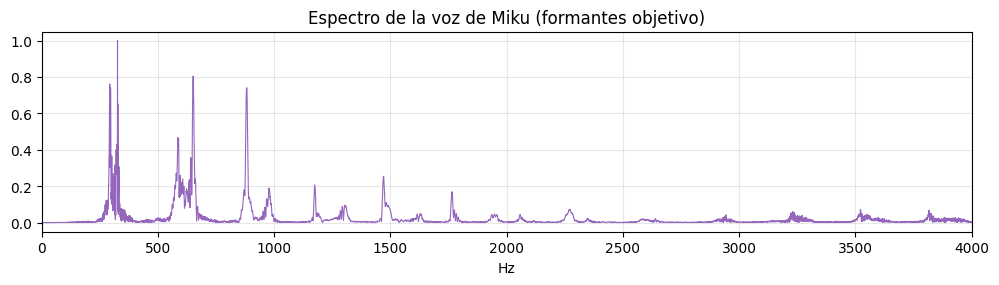

In [7]:
def load_miku_ref():
    if VOICE_B64:
        try:
            import soundfile as sf
            y, _ = sf.read(io.BytesIO(base64.b64decode(VOICE_B64)))
            return normalize_audio(ensure_mono_float(y)), "voz Miku incluida (CyberDiva V4)"
        except Exception as e:
            print("  (voz embebida no disponible:", str(e)[:60], ")")
    for p in ("voces/miku_voice.wav", "miku_voice.wav"):
        if os.path.exists(p):
            import librosa
            y, _ = librosa.load(p, sr=SR, mono=True)
            return normalize_audio(ensure_mono_float(y)), "local: " + p
    return synth_vowel(520.0, "i", dur=0.6, seed=2026), "vocal sintética (respaldo)"

miku_ref, mref = load_miku_ref()
print("Referencia de timbre:", mref, "(%.2f s)" % (len(miku_ref) / SR))
f, mag = compute_rfft(miku_ref)
plt.figure(figsize=(12, 2.6)); plt.plot(f, mag / (mag.max() + 1e-9), lw=0.8, color="tab:purple")
plt.xlim(0, 4000); plt.title("Espectro de la voz de Miku (formantes objetivo)"); plt.xlabel("Hz")
plt.grid(alpha=0.3); plt.show()
display(Audio(miku_ref, rate=SR))


## 5. Tu voz de entrada — **en vivo con audios nuevos**
Elige la fuente:
- **Subir** un archivo (Colab): deja `USE_MIC = False` y sube tu `.wav`/`.mp3`.
- **Micrófono en vivo** (Colab): pon `USE_MIC = True` y canta al ejecutar la celda.
- **Local:** pon la ruta en `LOCAL_PATH`; si queda vacío, se usa una **voz de prueba** desafinada para ver el efecto.

Entrada (voz de prueba (desafinada)): 4.80 s


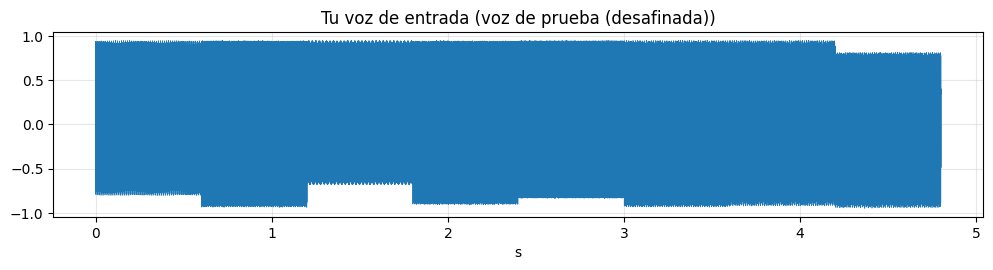

In [8]:
# ------------------ configuración de la entrada ------------------
USE_MIC        = False     # Colab: True para grabar tu voz en vivo con el micrófono
RECORD_SECONDS = 6.0       # duración de la grabación (si USE_MIC)
LOCAL_PATH     = ""        # local: ruta a tu voz .wav/.mp3 (vacío = voz de prueba)


def _record_colab(seconds, sr):
    '''Graba unos segundos del microfono en Colab (getUserMedia). Es E/S (captura del navegador),
    no materia del curso; el audio se decodifica y se remuestrea por interpolacion.'''
    from google.colab import output as colab_output
    from base64 import b64decode
    js = '''
    async function recordMic(sec){
      const stream = await navigator.mediaDevices.getUserMedia({audio:true});
      const rec = new MediaRecorder(stream); const chunks = [];
      rec.ondataavailable = e => chunks.push(e.data);
      const stopped = new Promise(r => rec.onstop = r);
      rec.start(); await new Promise(r => setTimeout(r, sec*1000));
      rec.stop(); await stopped; stream.getTracks().forEach(t => t.stop());
      const buf = await (new Blob(chunks)).arrayBuffer();
      const bytes = new Uint8Array(buf); let bin='';
      for (let i=0;i<bytes.length;i++) bin += String.fromCharCode(bytes[i]);
      return btoa(bin);
    }'''
    colab_output.eval_js(js)
    print("Grabando %.1f s... ¡canta ahora!" % seconds)
    b64 = colab_output.eval_js('recordMic(%f)' % float(seconds))
    open("mic_input.webm", "wb").write(b64decode(b64))
    import librosa
    y, _ = librosa.load("mic_input.webm", sr=sr, mono=True)
    return ensure_mono_float(y)


def synth_offkey_demo(seed=2026):
    '''Voz de prueba desafinada (Do mayor con +-30..50 cents de error) para demostrar el autotune.'''
    rng = np.random.default_rng(seed)
    midis = [60, 62, 64, 65, 67, 69, 67, 64]; vows = ["a","e","i","o","a","e","i","o"]
    parts = []
    for m, vw in zip(midis, vows):
        dt = float(rng.uniform(0.30, 0.5)) * (1 if rng.random() > 0.5 else -1)
        f = midi_to_freq(m + dt)
        parts.append(synth_vowel(f0=float(f), vowel=vw, dur=0.6, fs=SR, seed=int(rng.integers(1, 10**6))))
    return normalize_audio(np.concatenate(parts))


def load_input():
    if IN_COLAB and USE_MIC:
        try:
            return _record_colab(RECORD_SECONDS, SR), "micrófono en vivo"
        except Exception as e:
            print("  (sin micrófono:", str(e)[:60], ")")
    if IN_COLAB and not USE_MIC:
        try:
            from google.colab import files
            print("Sube tu voz (.wav/.mp3); o pulsa Cancelar para usar la voz de prueba.")
            up = files.upload()
            if up:
                import librosa
                y, _ = librosa.load(list(up.keys())[0], sr=SR, mono=True)
                return ensure_mono_float(y), "archivo subido"
        except Exception as e:
            print("  (sin upload:", str(e)[:60], ")")
    if LOCAL_PATH and os.path.exists(LOCAL_PATH):
        return load_audio(LOCAL_PATH, SR), "local: " + LOCAL_PATH
    return synth_offkey_demo(), "voz de prueba (desafinada)"


voz, vsrc = load_input()
print("Entrada (%s): %.2f s" % (vsrc, len(voz) / SR))
plt.figure(figsize=(12, 2.4)); plt.plot(np.arange(len(voz)) / SR, voz, lw=0.5)
plt.title("Tu voz de entrada (%s)" % vsrc); plt.xlabel("s"); plt.grid(alpha=0.3); plt.show()
display(Audio(voz, rate=SR))


## 6. Perillas del autotune
- **KEY / SCALE:** tonalidad y escala a la que se pega el tono (`chromatic`, `major`, `minor`, `pentatonic`).
- **STRENGTH** (0–1): 0 no corrige, 1 pega del todo (efecto duro).
- **RETUNE_SPEED** (0–1): 1 = enganche instantáneo (robótico); bajo = glissando suave.
- **MIKU_AMOUNT** (0–1): cuánto timbre de Miku se impone.
- **OCTAVE:** `"auto"` lleva tu voz al **registro de Miku** (sube octavas solo); un entero fija la octava (`0` = no subir).
- **GATE** (0–1): compuerta de silencios (más alto = calla más las pausas/respiración).

> La voz de entrada se **acondiciona** sola (quita ruido/DC, saca el click de grabación y sube el nivel si venía floja), así que sirve aunque el micrófono grabe bajo.

In [9]:
KEY          = "C"          # tónica: C, D, E, F, G, A, B (con # o b)
SCALE        = "major"      # chromatic | major | minor | pentatonic
STRENGTH     = 1.0          # 0..1
RETUNE_SPEED = 1.0          # 0..1  (1 = instantáneo)
MIKU_AMOUNT  = 0.9          # 0..1
OCTAVE       = "auto"       # "auto" = registro de Miku (sube octavas); o un entero (0 = no subir)
GATE         = 0.06         # 0..1  compuerta de silencios

res = mikutune(voz, SR, key=KEY, scale=SCALE, strength=STRENGTH, retune_speed=RETUNE_SPEED,
               octave=OCTAVE, miku_amount=MIKU_AMOUNT, gate=GATE, method="pv_formant", ref_miku=miku_ref)
auto, miku, info = res["auto"], res["miku"], res["info"]
print("Autotune listo (escala %s de %s, octava de registro K=%+d)." % (SCALE, KEY, res["params"]["octave_K"]))


Autotune listo (escala major de C, octava de registro K=+0).


## 7. Qué pasó con el tono (snap a la escala)
El tono medido (gris) se pega a las notas de la escala (rojo); el tono corregido (azul) queda sobre ellas.

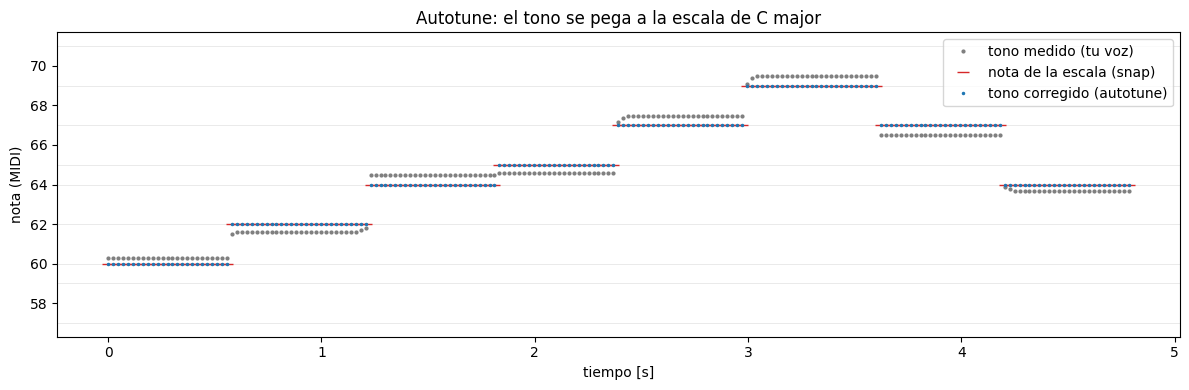

In [10]:
t = info["times"]
plt.figure(figsize=(12, 4))
plt.plot(t, info["orig_midi"], ".", ms=4, color="tab:gray", label="tono medido (tu voz)")
plt.plot(t, info["snapped_midi"], "_", ms=9, color="tab:red", label="nota de la escala (snap)")
corr = np.where(info["voiced"], info["orig_midi"] + info["corr"], np.nan)
plt.plot(t, corr, ".", ms=3, color="tab:blue", label="tono corregido (autotune)")
kpc = note_to_pitch_class(KEY); sset = set(SCALES[SCALE])
lo = int(np.nanmin(info["orig_midi"])) - 3; hi = int(np.nanmax(info["orig_midi"])) + 3
for m in range(lo, hi):
    if ((m - kpc) % 12) in sset:
        plt.axhline(m, color="0.9", lw=0.6, zorder=0)
plt.xlabel("tiempo [s]"); plt.ylabel("nota (MIDI)")
plt.title("Autotune: el tono se pega a la escala de %s %s" % (KEY, SCALE))
plt.legend(loc="upper right"); plt.tight_layout(); plt.show()


## 8. Escucha el A/B y descarga
**Entrada** (tu voz) · **Autotune** (afinada, tu timbre) · **Autotune + Miku** (afinada con voz de Miku). Compara los espectrogramas.

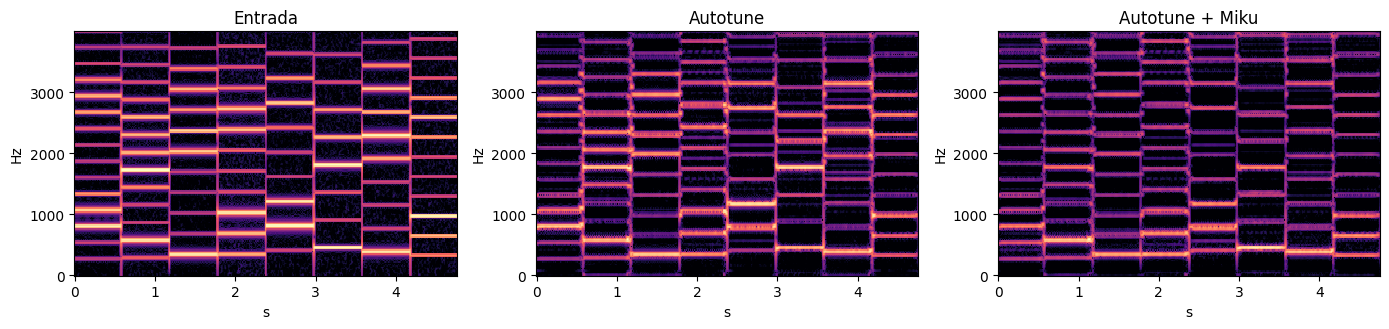

Entrada (tu voz):


Autotune (afinada, tu timbre):


Autotune + voz de Miku:


Guardado: miku_autotune_salida.wav


In [11]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.4))
for a, sig, ttl in [(ax[0], voz, "Entrada"), (ax[1], auto, "Autotune"),
                    (ax[2], miku, "Autotune + Miku")]:
    X = stft(sig, n_fft=1024, hop=256); S = 20*np.log10(np.abs(X).T + 1e-6)
    ff = np.fft.rfftfreq(1024, 1.0/SR); mm = ff <= 4000
    a.pcolormesh(np.arange(X.shape[0])*256/SR, ff[mm], S[mm], shading="auto",
                 cmap="magma", vmin=S.max()-70, vmax=S.max())
    a.set_title(ttl); a.set_xlabel("s"); a.set_ylabel("Hz")
plt.tight_layout(); plt.show()

print("Entrada (tu voz):");            display(Audio(normalize_audio(voz), rate=SR))
print("Autotune (afinada, tu timbre):"); display(Audio(normalize_audio(auto), rate=SR))
print("Autotune + voz de Miku:");       display(Audio(normalize_audio(miku), rate=SR))

import soundfile as sf
out_name = "miku_autotune_salida.wav"
sf.write(out_name, normalize_audio(miku), SR)
print("Guardado:", out_name)
if IN_COLAB:
    try:
        from google.colab import files
        files.download(out_name)
    except Exception as e:
        print("(descarga manual desde el panel de archivos)", str(e)[:60])


## 9. Discusión

- **Cómo funciona el "snap":** se estima el tono f0 (pYIN/autocorrelación), se pasa a número MIDI
  (`m = 69 + 12·log2(f/440)`) y se redondea a la **nota más cercana de la escala**; la diferencia en
  semitonos se corrige con el **phase vocoder preservando formantes** (así la vocal no se vuelve
  "ardilla" al subir el tono). Como se corrige por **bloques con overlap-add**, la **duración se
  conserva** (no se acelera ni frena la voz).
- **Por qué suena a Miku:** se estima la **envolvente de formantes** de una voz real de Miku (por
  **cepstrum**) y se **impone** sobre tu voz afinada como una máscara espectral `H = env_Miku/env_tuya`.
  El tono es tuyo (tu melodía), pero el **color** (formantes) es de Miku.
- **Registro de Miku:** una voz grave (p. ej. ~120 Hz) no suena a Miku aunque esté afinada. Con
  `OCTAVE = "auto"` se calcula un número **entero de octavas** para llevar la mediana del tono al
  registro de Miku (~466 Hz) **conservando el contorno melódico**; la corrección del "snap" (pocos
  semitonos) se maneja aparte de la octava para no recortarla.
- **Robustez del micrófono:** la voz de entrada se **acondiciona** (quita DC, pasa-altos para el rumble,
  recorta el *click* de inicio y normaliza por un pico robusto) y los cuadros sin voz/silencio se
  **silencian** (compuerta), evitando que se sintetice ruido tonal en las pausas.
- **Efecto T-Pain:** con `RETUNE_SPEED = 1` y `STRENGTH = 1` el enganche es instantáneo (robótico);
  bajando `RETUNE_SPEED` el tono llega a la nota con un **glissando** más natural.
- **Límites:** es **monofónico** (una voz a la vez) y funciona **por lotes** (graba/sube → procesa →
  reproduce), no en streaming de latencia cero como un plugin en vivo. Saltos de tono muy grandes
  degradan el phase vocoder (por eso se acota el desplazamiento).
- **Trabajo futuro (fuera del eje DSP del ramo):** clonación de timbre con RVC/so-vits, síntesis tipo
  OpenUTAU, y una versión en **tiempo real** por bloques (`sounddevice`) o como plugin (JUCE/Reaper).
- **Reutilización:** el núcleo DSP (`vocoder.py`) viene del proyecto del phase vocoder (artículo de
  Dolson 1986); lo nuevo aquí es el **motor de autotune** (`autotune.py`: snap a escala, corrección
  variable en el tiempo y transferencia de formantes de Miku).
